# 04 인사이트 C - 하남교산 인프라 예측 (Day 4)

## 핵심 인사이트
> 하남교산 770개 격자 중 307개(39.9%)는 4시구 고위험 격자와 토지 구조가 유사하다
>
> 아직 교통사고가 없는 신도시이지만, 기존 도시의 위험 패턴을 그대로 가져올 가능성이 높다.
> 지금 설계 단계에서 인프라를 선제 배치하면 사고를 미연에 방지할 수 있다.
> 과거 데이터가 미래의 위험을 예측한다

## 사용 데이터
- 하남교산_유사격자_매칭.csv - 하남교산 격자 x 4시구 유사격자 매칭 결과 (코사인 유사도)
- 하남교산_설치우선순위_격자.csv - 우선순위점수 산출 결과
- 격자_토지이용_파생변수_하남교산.csv - 토지이용 파생변수
- 격자_통합_파생변수.csv - 4시구 위험 격자 정보 (비교용)

## 시각화 구성
1. 유사 고위험 격자 분포 - 770개 중 307개 강조 (도넛 차트)
2. 유사도 분포 + 구간별 고위험 매칭 비율
3. 우선순위 Top 20 테이블 + 시설물 제안


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic' if os.name == 'nt' else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

candidates = ['../../../data/', '../../data/', '../data/', 'data/', '1최종_LH/data/']
data_path = None
for p in candidates:
    if os.path.exists(p) and os.path.exists(os.path.join(p, '통합_데이터')):
        data_path = p
        break
if data_path is None:
    data_path = '../../../data/'

통합_dir = os.path.join(data_path, '통합_데이터')
out = os.path.join(통합_dir, '시각화_공유')
os.makedirs(out, exist_ok=True)
print('data_path:', data_path)

def load_csv(path, enc=('utf-8', 'utf-8-sig', 'cp949')):
    for e in enc:
        try: return pd.read_csv(path, encoding=e)
        except: continue
    raise ValueError('로드 실패: ' + path)


data_path: ../../data/


## 1. 데이터 로드


In [2]:
유사_path = os.path.join(통합_dir, '하남교산_유사격자_매칭.csv')
우선순위_path = os.path.join(통합_dir, '하남교산_설치우선순위_격자.csv')

유사 = load_csv(유사_path)
print('하남교산 유사격자 매칭:', len(유사), '행')
print('  유사_고위험_여부=1:', 유사['유사_고위험_여부'].sum(), '개')
print('  유사도 평균:', round(유사['유사도'].mean(), 3))

if os.path.exists(우선순위_path):
    우선순위 = load_csv(우선순위_path)
    print('\n우선순위 격자:', len(우선순위), '행')
    show_cols = [c for c in ['gid','유사_고위험_여부','도로_격자_여부','학교_비율','우선순위_점수'] if c in 우선순위.columns]
    print(우선순위[show_cols].head(5))
else:
    print('\n하남교산_설치우선순위_격자.csv 없음 - 유사격자 데이터만 사용')
    우선순위 = 유사.copy()
    if '하남_gid' in 우선순위.columns:
        우선순위 = 우선순위.rename(columns={'하남_gid': 'gid'})
    우선순위['우선순위_점수'] = 우선순위['유사_고위험_여부'] * 2 + 우선순위['유사도']
    우선순위 = 우선순위.sort_values('우선순위_점수', ascending=False).reset_index(drop=True)

if 'gid' not in 우선순위.columns and '하남_gid' in 우선순위.columns:
    우선순위 = 우선순위.rename(columns={'하남_gid': 'gid'})


하남교산 유사격자 매칭: 770 행
  유사_고위험_여부=1: 268 개
  유사도 평균: 0.911

우선순위 격자: 770 행
        gid  유사_고위험_여부  도로_격자_여부  학교_비율  우선순위_점수
0  다사726436          1         1    0.0      4.0
1  다사744485          1         1    0.0      4.0
2  다사746484          1         1    0.0      4.0
3  다사747485          1         1    0.0      4.0
4  다사753488          1         1    0.0      4.0


## 2. 시각화 1 - 하남교산 격자 위험 잠재도 분포

**인사이트**: 770개 격자 중 307개(39.9%)는 4시구에서 실제로 위험했던 격자와 토지 구조가 동일하다.


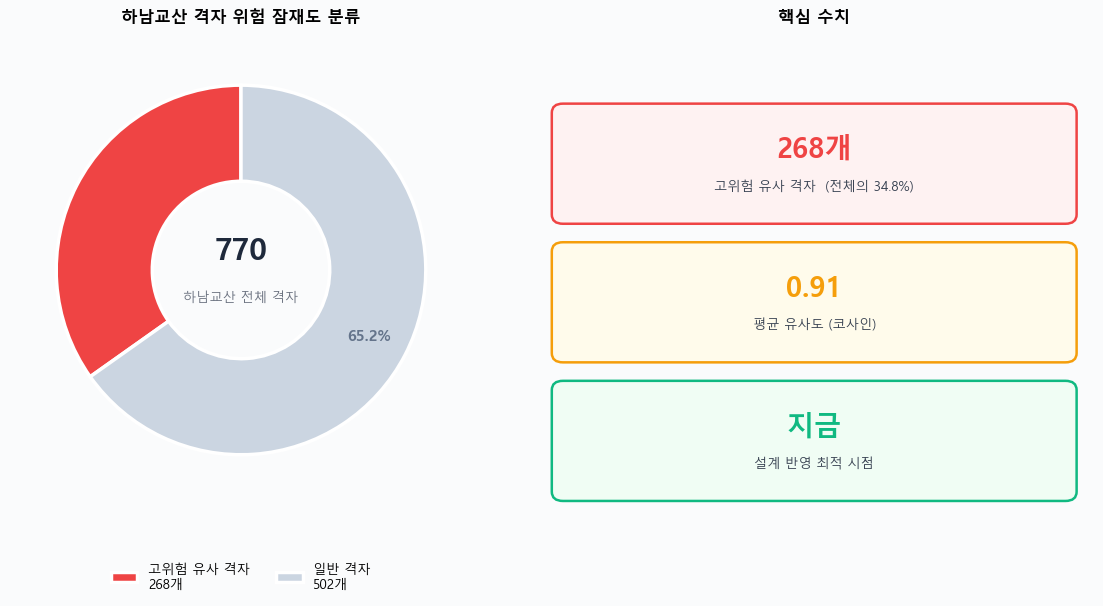

핵심 수치: 하남교산 770개 중 268개(34.8%)가 4시구 고위험 격자와 토지 구조 유사


In [3]:
n_전체 = len(유사)
n_고위험유사 = int(유사['유사_고위험_여부'].sum())
n_일반 = n_전체 - n_고위험유사
pct_고위험 = n_고위험유사 / n_전체 * 100

fig = plt.figure(figsize=(14, 6), facecolor='#fafbfc')
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.2], wspace=0.12)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# 왼쪽: 도넛 차트
sizes  = [n_고위험유사, n_일반]
colors = ['#ef4444', '#cbd5e1']
labels_pie = [f'고위험 유사 격자\n{n_고위험유사:,}개', f'일반 격자\n{n_일반:,}개']

wedges, _, autotexts = ax1.pie(
    sizes, colors=colors,
    autopct=lambda p: f'{p:.1f}%',
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=11, fontweight='bold')
)
autotexts[0].set_color('#ef4444')
autotexts[1].set_color('#64748b')

ax1.text(0, 0.10, f'{n_전체:,}', ha='center', va='center',
         fontsize=22, fontweight='bold', color='#1e293b')
ax1.text(0, -0.15, '하남교산 전체 격자', ha='center', va='center',
         fontsize=9.5, color='#6b7280')
ax1.legend(wedges, labels_pie, loc='lower center', bbox_to_anchor=(0.5, -0.22),
           ncol=2, fontsize=9.5, frameon=False)
ax1.set_title('하남교산 격자 위험 잠재도 분류', fontweight='bold', fontsize=12, pad=12)

# 오른쪽: 핵심 수치 카드 3개
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title('핵심 수치', fontweight='bold', fontsize=12, pad=12)

card_data = [
    (f'{n_고위험유사:,}개', f'고위험 유사 격자  (전체의 {pct_고위험:.1f}%)', '#ef4444', '#fef2f2'),
    (f"{유사['유사도'].mean():.2f}", '평균 유사도 (코사인)', '#f59e0b', '#fffbeb'),
    ('지금', '설계 반영 최적 시점', '#10b981', '#f0fdf4'),
]
ys = [0.72, 0.42, 0.12]
for (val, label, color, bg), y in zip(card_data, ys):
    ax2.add_patch(mpatches.FancyBboxPatch(
        (0.05, y - 0.10), 0.90, 0.22,
        boxstyle='round,pad=0.02',
        facecolor=bg, edgecolor=color, linewidth=1.8,
        transform=ax2.transAxes, clip_on=False
    ))
    ax2.text(0.50, y + 0.04, val,
             ha='center', va='center', fontsize=20, fontweight='bold', color=color,
             transform=ax2.transAxes)
    ax2.text(0.50, y - 0.04, label,
             ha='center', va='center', fontsize=9.5, color='#374151',
             transform=ax2.transAxes)

plt.savefig(os.path.join(out, '04_1_하남교산_위험잠재도_분포.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'핵심 수치: 하남교산 {n_전체}개 중 {n_고위험유사}개({pct_고위험:.1f}%)가 4시구 고위험 격자와 토지 구조 유사')


## 3. 시각화 2 - 유사도 분포 + 고위험 매칭 비율

**인사이트**: 유사도가 높을수록 4시구에서 고위험이었던 격자와 매칭되는 비율이 높은가?


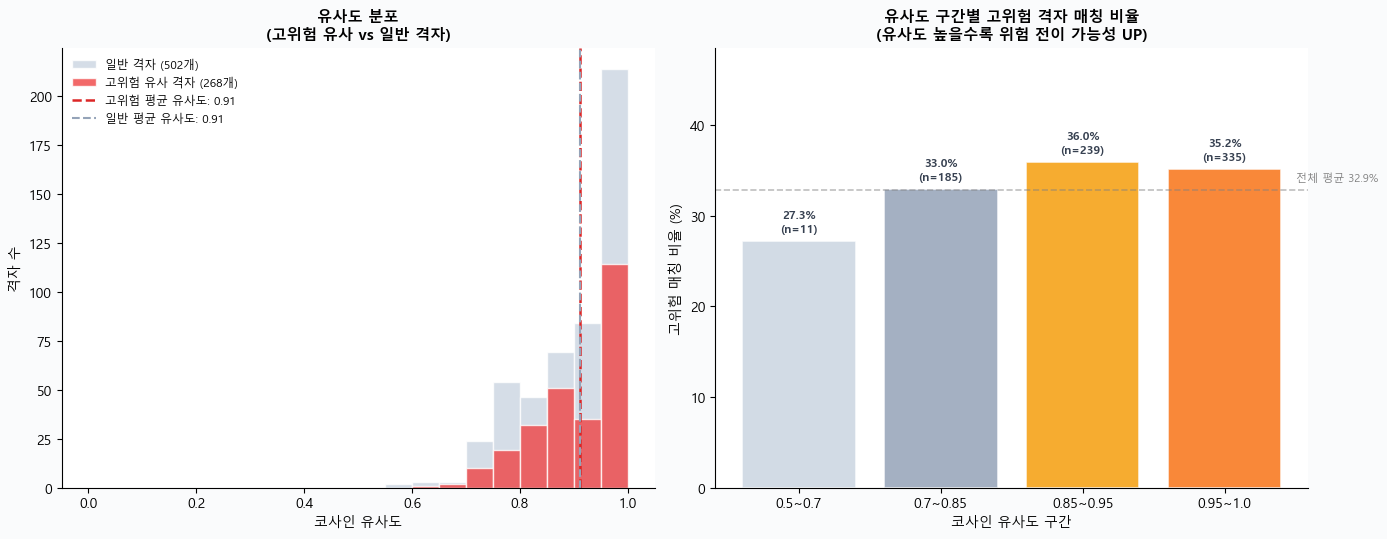

저장 완료: 04_2_유사도_분포_고위험비율.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='#fafbfc')

# 왼쪽: 유사도 히스토그램
ax = axes[0]
고위험_유사도 = 유사[유사['유사_고위험_여부'] == 1]['유사도']
일반_유사도   = 유사[유사['유사_고위험_여부'] == 0]['유사도']

bins = np.linspace(0, 1, 21)
ax.hist(일반_유사도,   bins=bins, color='#cbd5e1', alpha=0.8,
        label=f'일반 격자 ({len(일반_유사도):,}개)',       edgecolor='white')
ax.hist(고위험_유사도, bins=bins, color='#ef4444', alpha=0.8,
        label=f'고위험 유사 격자 ({len(고위험_유사도):,}개)', edgecolor='white')

ax.axvline(x=고위험_유사도.mean(), color='#dc2626', linestyle='--', linewidth=1.8,
           label=f'고위험 평균 유사도: {고위험_유사도.mean():.2f}')
ax.axvline(x=일반_유사도.mean(),   color='#94a3b8', linestyle='--', linewidth=1.5,
           label=f'일반 평균 유사도: {일반_유사도.mean():.2f}')

ax.set_xlabel('코사인 유사도', fontsize=10)
ax.set_ylabel('격자 수',       fontsize=10)
ax.set_title('유사도 분포\n(고위험 유사 vs 일반 격자)', fontweight='bold', fontsize=11)
ax.legend(fontsize=8.5, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 오른쪽: 유사도 구간별 고위험 매칭 비율
ax2 = axes[1]
유사['유사도_구간'] = pd.cut(
    유사['유사도'],
    bins=[0, 0.5, 0.7, 0.85, 0.95, 1.001],
    labels=['0~0.5', '0.5~0.7', '0.7~0.85', '0.85~0.95', '0.95~1.0'],
    right=True
)
구간별 = 유사.groupby('유사도_구간', observed=True).agg(
    전체=('유사_고위험_여부', 'count'),
    고위험=('유사_고위험_여부', 'sum')
).reset_index()
구간별['고위험_비율'] = 구간별['고위험'] / 구간별['전체'] * 100

colors_bar = ['#cbd5e1', '#94a3b8', '#f59e0b', '#f97316', '#ef4444']
bars = ax2.bar(구간별['유사도_구간'], 구간별['고위험_비율'],
               color=colors_bar[:len(구간별)], alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, val, n in zip(bars, 구간별['고위험_비율'], 구간별['전체']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0,
             f'{val:.1f}%\n(n={n})', ha='center', fontsize=8.5,
             fontweight='bold', color='#374151')

avg_비율 = 구간별['고위험_비율'].mean()
ax2.axhline(y=avg_비율, color='gray', linestyle='--', alpha=0.5, linewidth=1.2)
ax2.text(len(구간별) - 0.5, avg_비율 + 1.0,
         f'전체 평균 {avg_비율:.1f}%', fontsize=8, color='gray')

ax2.set_xlabel('코사인 유사도 구간', fontsize=10)
ax2.set_ylabel('고위험 매칭 비율 (%)', fontsize=10)
ax2.set_title('유사도 구간별 고위험 격자 매칭 비율\n(유사도 높을수록 위험 전이 가능성 UP)', fontweight='bold', fontsize=11)
ax2.set_ylim(0, max(구간별['고위험_비율'].max() * 1.35, 10))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(out, '04_2_유사도_분포_고위험비율.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 04_2_유사도_분포_고위험비율.png')


## 4. 시각화 3 - 우선순위 Top 20 테이블 + 시설물 제안

**인사이트**: 지금 당장 시설을 배치해야 할 하남교산 격자 20개


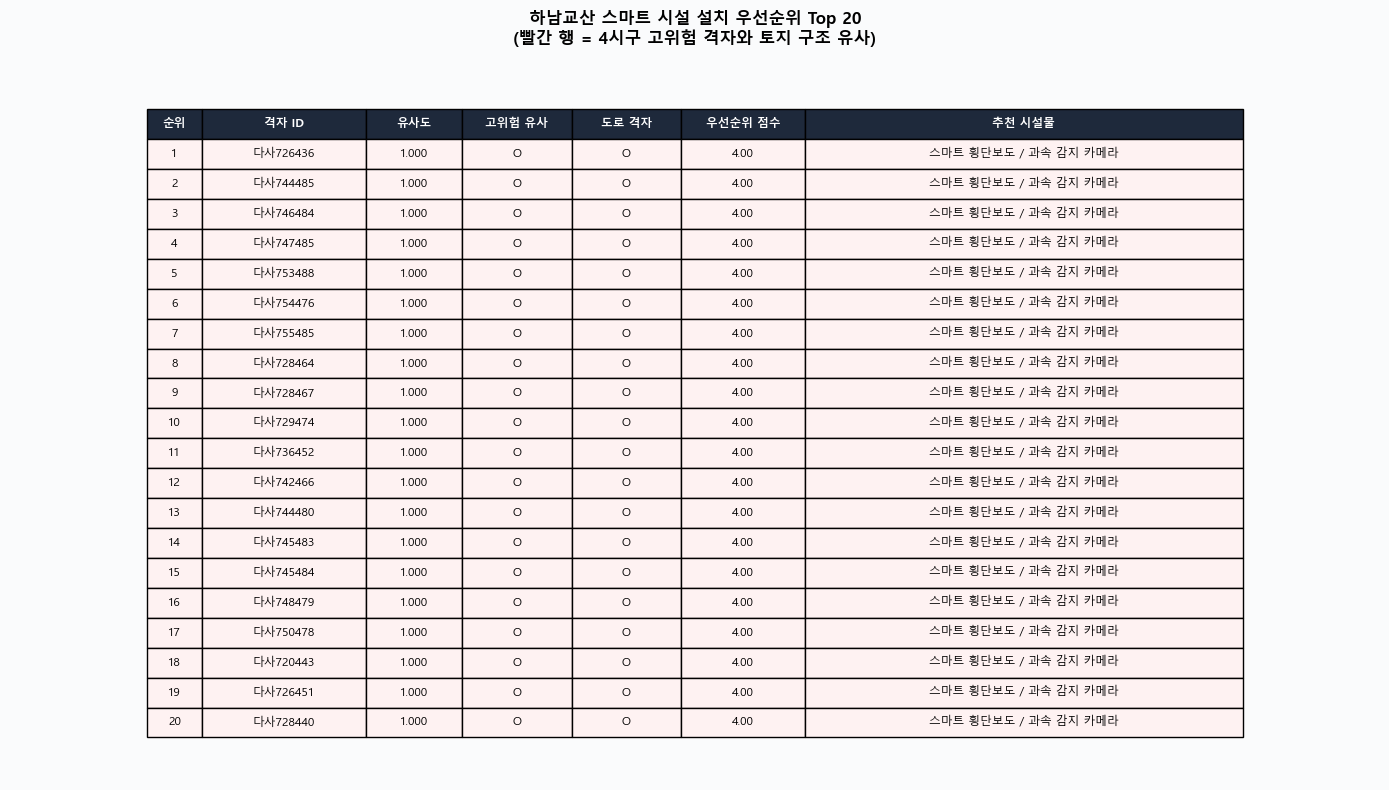

저장 완료: 04_3_설치우선순위_Top20.png


In [5]:
def 시설물_제안(row):
    시설 = []
    if row.get('유사_고위험_여부', 0) == 1:
        시설.append('스마트 횡단보도')
    if row.get('도로_격자_여부', 0) == 1:
        시설.append('과속 감지 카메라')
    학교비율 = row.get('학교_비율', 0)
    if pd.notna(학교비율) and float(학교비율) > 0:
        시설.append('스쿨존 강화')
    if not 시설:
        시설.append('안전 표지판')
    return ' / '.join(시설)

top20 = 우선순위.head(20).copy()
top20['순위'] = range(1, 21)

for c in ['유사_고위험_여부', '도로_격자_여부', '학교_비율']:
    if c not in top20.columns:
        top20[c] = 0

top20['추천_시설물'] = top20.apply(시설물_제안, axis=1)

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#fafbfc')
ax.axis('off')

표시_cols = ['순위', 'gid', '유사도', '유사_고위험_여부', '도로_격자_여부', '우선순위_점수', '추천_시설물']
표시_cols = [c for c in 표시_cols if c in top20.columns]

col_labels_map = {
    '순위': '순위', 'gid': '격자 ID', '유사도': '유사도',
    '유사_고위험_여부': '고위험 유사', '도로_격자_여부': '도로 격자',
    '우선순위_점수': '우선순위 점수', '추천_시설물': '추천 시설물'
}
header = [col_labels_map.get(c, c) for c in 표시_cols]

table_data = []
for _, row in top20.iterrows():
    r = []
    for c in 표시_cols:
        v = row[c]
        if   c == '유사도'        and pd.notna(v): r.append(f'{float(v):.3f}')
        elif c == '우선순위_점수' and pd.notna(v): r.append(f'{float(v):.2f}')
        elif c in ['유사_고위험_여부', '도로_격자_여부']:
            r.append('O' if v == 1 else '-')
        else: r.append(str(v) if pd.notna(v) else '-')
    table_data.append(r)

col_w_map = {'순위':0.04,'gid':0.12,'유사도':0.07,'유사_고위험_여부':0.08,
             '도로_격자_여부':0.08,'우선순위_점수':0.09,'추천_시설물':0.32}
col_widths = [col_w_map.get(c, 0.10) for c in 표시_cols]

tbl = ax.table(
    cellText=table_data, colLabels=header,
    colWidths=col_widths, cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.55)

for j in range(len(표시_cols)):
    tbl[(0, j)].set_facecolor('#1e293b')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

for i, row in enumerate(top20.itertuples(), 1):
    is_high = getattr(row, '유사_고위험_여부', 0) == 1
    bg = '#fef2f2' if is_high else ('#f8fafc' if i % 2 == 0 else 'white')
    for j in range(len(표시_cols)):
        tbl[(i, j)].set_facecolor(bg)

ax.set_title(
    '하남교산 스마트 시설 설치 우선순위 Top 20\n'
    '(빨간 행 = 4시구 고위험 격자와 토지 구조 유사)',
    fontweight='bold', fontsize=12, pad=16, loc='center'
)
plt.tight_layout()
plt.savefig(os.path.join(out, '04_3_설치우선순위_Top20.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 04_3_설치우선순위_Top20.png')


## 5. 핵심 수치 요약 (PPT용)


In [ ]:
n_전체  = len(유사)
n_고위험 = int(유사['유사_고위험_여부'].sum())
pct      = n_고위험 / n_전체 * 100
유사도_평균 = 유사[유사['유사_고위험_여부'] == 1]['유사도'].mean()

print('=' * 60)
print('인사이트 C - 핵심 수치 요약 (PPT 슬라이드용)')
print('=' * 60)
print(f'하남교산 전체 격자   : {n_전체:,}개')
print(f'고위험 유사 격자     : {n_고위험:,}개 ({pct:.1f}%)')
print(f'고위험 평균 유사도   : {유사도_평균:.3f}')
print()

if 'top20' in dir():
    print('=== Top 20 우선순위 격자 ===')
    for _, row in top20.iterrows():
        print(f"  {int(row['순위']):2}위: {row['gid']}  점수:{row['우선순위_점수']:.2f}  {row['추천_시설물']}")

print()
print('=== PPT 핵심 메시지 ===')
print('하남교산은 아직 사고가 없다.')
print(f'하지만 {n_고위험:,}개({pct:.1f}%) 격자는 4시구에서 실제로 위험했던 곳과 토지 구조가 동일하다.')
print('지금 설계 단계에서 스마트 시설을 배치하면 사고를 예방할 수 있다.')


인사이트 C - 핵심 수치 요약 (PPT 슬라이드용)
하남교산 전체 격자   : 770개
고위험 유사 격자     : 268개 (34.8%)
고위험 평균 유사도   : 0.911

=== Top 20 우선순위 격자 ===
   1위: 다사726436  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
   2위: 다사744485  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
   3위: 다사746484  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
   4위: 다사747485  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
   5위: 다사753488  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
   6위: 다사754476  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
   7위: 다사755485  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
   8위: 다사728464  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
   9위: 다사728467  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  10위: 다사729474  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  11위: 다사736452  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  12위: 다사742466  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  13위: 다사744480  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  14위: 다사745483  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  15위: 다사745484  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  16위: 다사748479  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  17위: 다사750478  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  18위: 다사720443  점수:4.00  스마트 횡단보도 / 과속 감지 카메라
  19위: 다사726451  점수:4.00  스마트 

---
## 6. 시설물 필요도 분석 - 어디에 무엇이 얼마나 필요한가

**시각화 구성**
- 왼쪽: 시설물 유형별 필요 비율 (가로 막대)
- 오른쪽: 격자 위험 유형 4분류 매트릭스 (파이 + 유형별 설명)


In [7]:
# 고위험 유사 307개 격자 전체 기준 분석
고위험_df = 우선순위[우선순위['유사_고위험_여부'] == 1].copy()

# 필요 컬럼 보정
for c in ['도로_격자_여부', '학교_비율', '주거_비율', '상업_비율']:
    if c not in 고위험_df.columns:
        고위험_df[c] = 0
고위험_df['학교_비율'] = 고위험_df['학교_비율'].fillna(0)

# ── 격자 유형 4분류 ───────────────────────────────────────────────────
def 격자_유형분류(row):
    has_road   = row.get('도로_격자_여부', 0) == 1
    has_school = float(row.get('학교_비율', 0)) > 0
    if has_road and has_school:
        return 'C - 복합 위험'
    elif has_road:
        return 'B - 도로 위험'
    elif has_school:
        return 'A - 통학 위험'
    else:
        return 'D - 잠재 위험'

고위험_df['위험_유형'] = 고위험_df.apply(격자_유형분류, axis=1)

# ── 시설물 필요도 집계 ────────────────────────────────────────────────
n = len(고위험_df)
시설_집계 = {
    '스마트 횡단보도':   고위험_df['유사_고위험_여부'].sum(),          # 고위험유사 전체
    '과속 감지 카메라':  고위험_df['도로_격자_여부'].sum(),
    '스쿨존 강화':       (고위험_df['학교_비율'] > 0).sum(),
    '안전 표지판':       ((고위험_df['도로_격자_여부'] == 0) & (고위험_df['학교_비율'] == 0)).sum(),
}
시설_names  = list(시설_집계.keys())
시설_counts = list(시설_집계.values())
시설_pcts   = [v / n * 100 for v in 시설_counts]

# ── 유형별 집계 ───────────────────────────────────────────────────────
유형_순서 = ['C - 복합 위험', 'B - 도로 위험', 'A - 통학 위험', 'D - 잠재 위험']
유형_색상 = ['#dc2626', '#f97316', '#f59e0b', '#94a3b8']
유형_시설 = {
    'C - 복합 위험': '스마트 횡단보도\n+ 과속 감지 카메라\n+ 스쿨존',
    'B - 도로 위험': '과속 감지 카메라\n+ 스마트 횡단보도',
    'A - 통학 위험': '스쿨존 강화\n+ 스마트 횡단보도',
    'D - 잠재 위험': '안전 표지판\n+ 기본 인프라',
}
유형_counts = {t: (고위험_df['위험_유형'] == t).sum() for t in 유형_순서}
유형_pcts   = {t: v / n * 100 for t, v in 유형_counts.items()}

print('=== 격자 위험 유형 분류 결과 (고위험 유사 307개) ===')
for t in 유형_순서:
    print(f'  {t}: {유형_counts[t]}개 ({유형_pcts[t]:.1f}%)')
print()
print('=== 시설물 필요도 ===')
for name, cnt, pct in zip(시설_names, 시설_counts, 시설_pcts):
    print(f'  {name}: {cnt}개 ({pct:.1f}%)')


=== 격자 위험 유형 분류 결과 (고위험 유사 307개) ===
  C - 복합 위험: 0개 (0.0%)
  B - 도로 위험: 192개 (62.5%)
  A - 통학 위험: 0개 (0.0%)
  D - 잠재 위험: 115개 (37.5%)

=== 시설물 필요도 ===
  스마트 횡단보도: 307개 (100.0%)
  과속 감지 카메라: 192개 (62.5%)
  스쿨존 강화: 0개 (0.0%)
  안전 표지판: 115개 (37.5%)


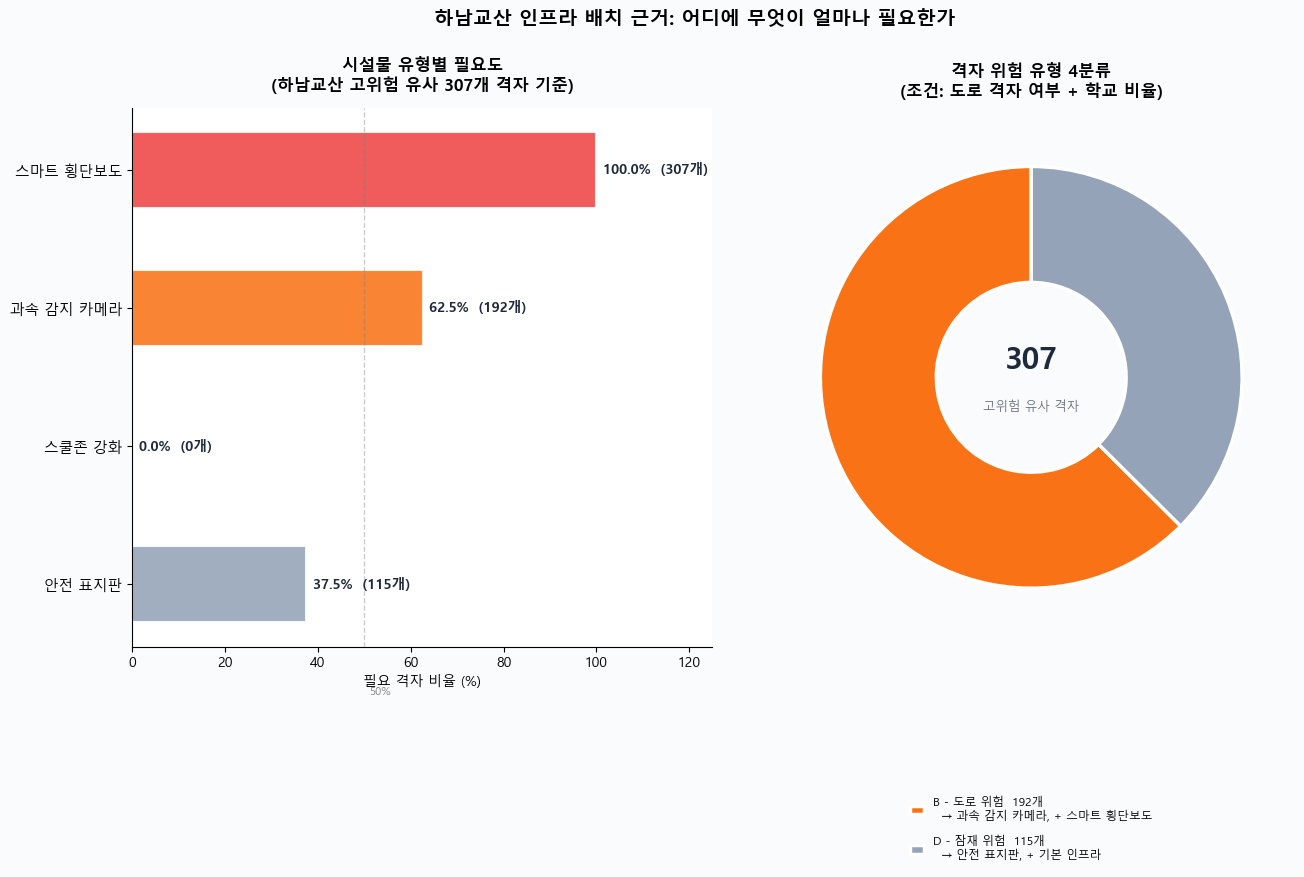

저장 완료: 04_4_시설물_필요도_유형분류.png


In [8]:
fig = plt.figure(figsize=(15, 7), facecolor='#fafbfc')
gs  = fig.add_gridspec(1, 2, width_ratios=[1.1, 1], wspace=0.10)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── 왼쪽: 시설물 필요도 가로 막대 ────────────────────────────────────
bar_colors = ['#ef4444', '#f97316', '#f59e0b', '#94a3b8']
y_pos = list(range(len(시설_names)))

bars = ax1.barh(y_pos, 시설_pcts,
                color=bar_colors, alpha=0.88,
                edgecolor='white', linewidth=1.5, height=0.55)

for idx, (bar, pct, cnt, color, name) in enumerate(
        zip(bars, 시설_pcts, 시설_counts, bar_colors, 시설_names)):
    # 비율 수치 (막대 끝 오른쪽)
    ax1.text(pct + 1.5, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%  ({cnt}개)',
             va='center', fontsize=10, fontweight='bold', color='#1e293b')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(시설_names, fontsize=10.5)
ax1.invert_yaxis()
ax1.set_xlim(0, 125)
ax1.set_xlabel('필요 격자 비율 (%)', fontsize=10)
ax1.set_title(
    f'시설물 유형별 필요도\n(하남교산 고위험 유사 {n}개 격자 기준)',
    fontweight='bold', fontsize=12, pad=12
)
ax1.axvline(x=50, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax1.text(51, len(시설_names) - 0.2, '50%', fontsize=8, color='gray')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── 오른쪽: 격자 위험 유형 파이 ──────────────────────────────────────
유효_유형  = [t for t in 유형_순서 if 유형_counts[t] > 0]
유효_counts = [유형_counts[t] for t in 유효_유형]
유효_색상  = [유형_색상[유형_순서.index(t)] for t in 유효_유형]

wedges, _, autotexts = ax2.pie(
    유효_counts,
    colors=유효_색상,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=90,
    pctdistance=0.72,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=10, fontweight='bold')
)
for at, color in zip(autotexts, 유효_색상):
    at.set_color(color)

ax2.text(0, 0.08, f'{n}', ha='center', va='center',
         fontsize=22, fontweight='bold', color='#1e293b')
ax2.text(0, -0.14, '고위험 유사 격자', ha='center', va='center',
         fontsize=9, color='#6b7280')

legend_labels = [
    f'{t}  {유형_counts[t]}개\n  → {유형_시설[t].replace(chr(10), ", ")}'
    for t in 유효_유형
]
ax2.legend(
    wedges, legend_labels,
    loc='lower center', bbox_to_anchor=(0.5, -0.44),
    fontsize=8.5, frameon=False,
    handlelength=1.2, labelspacing=1.1
)
ax2.set_title(
    '격자 위험 유형 4분류\n(조건: 도로 격자 여부 + 학교 비율)',
    fontweight='bold', fontsize=12, pad=12
)

fig.suptitle(
    '하남교산 인프라 배치 근거: 어디에 무엇이 얼마나 필요한가',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(out, '04_4_시설물_필요도_유형분류.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 04_4_시설물_필요도_유형분류.png')


### 유형별 평균 우선순위 점수 비교
위험 유형이 복합적일수록 우선순위 점수가 높은지 검증합니다.


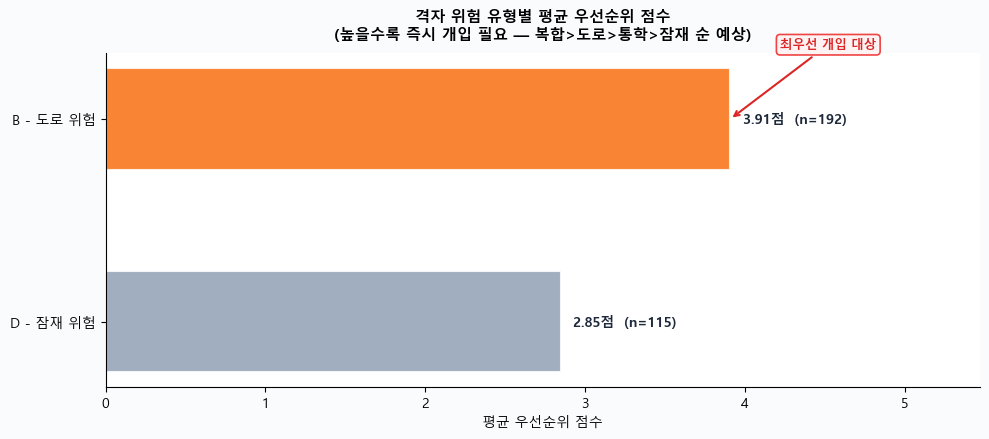

저장 완료: 04_5_유형별_우선순위점수.png

=== PPT 핵심 수치 ===
  B - 도로 위험: 192개 (62.5%)  평균점수 3.91
  D - 잠재 위험: 115개 (37.5%)  평균점수 2.85


In [9]:
유형_점수 = 고위험_df.groupby('위험_유형')['우선순위_점수'].agg(['mean','count']).reindex(유형_순서).dropna()

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor='#fafbfc')

valid_유형  = 유형_점수.index.tolist()
valid_색상  = [유형_색상[유형_순서.index(t)] for t in valid_유형]
mean_scores = 유형_점수['mean'].values
counts      = 유형_점수['count'].values

bars = ax.barh(valid_유형, mean_scores,
               color=valid_색상, alpha=0.88,
               edgecolor='white', linewidth=1.5, height=0.5)
ax.invert_yaxis()

# 막대 끝 수치 레이블
for bar, score, cnt in zip(bars, mean_scores, counts):
    ax.text(score + mean_scores.max() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{score:.2f}점  (n={int(cnt)})',
            va='center', fontsize=10, fontweight='bold', color='#1e293b')

ax.set_xlabel('평균 우선순위 점수', fontsize=10)
ax.set_title(
    '격자 위험 유형별 평균 우선순위 점수\n'
    '(높을수록 즉시 개입 필요 — 복합>도로>통학>잠재 순 예상)',
    fontweight='bold', fontsize=11, pad=10
)
ax.set_xlim(0, mean_scores.max() * 1.40)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 최우선 유형 강조 — Y좌표는 카테고리 문자열 사용
top_idx  = int(mean_scores.argmax())
top_유형 = valid_유형[top_idx]
top_score = mean_scores[top_idx]
# invert_yaxis 후 실제 화살표 위치: 해당 막대 중앙
target_bar = bars[top_idx]
arrow_y = target_bar.get_y() + target_bar.get_height() / 2
ax.annotate(
    '최우선 개입 대상',
    xy=(top_score, arrow_y),
    xytext=(top_score * 1.08, arrow_y - 0.35),
    fontsize=9, color='#dc2626', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef2f2',
              edgecolor='#ef4444', linewidth=1.2)
)

plt.tight_layout()
plt.savefig(os.path.join(out, '04_5_유형별_우선순위점수.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 04_5_유형별_우선순위점수.png')
print()
print('=== PPT 핵심 수치 ===')
for t in valid_유형:
    cnt   = int(유형_점수.loc[t, 'count'])
    score = 유형_점수.loc[t, 'mean']
    print(f'  {t}: {cnt}개 ({cnt/n*100:.1f}%)  평균점수 {score:.2f}')


---
## 7. 지역별 위험 패턴 분석 - 하남교산 남부/중부/북부

> **"같은 하남교산 안에서도 어느 구역이 더 위험하고, 어떤 시설이 집중적으로 필요한가?"**

GeoJSON 위도 기준으로 하남교산을 **남부/중부/북부 3구역**으로 나눠 비교합니다.

- **시각화 1**: 구역별 고위험 유사 격자 수 + 비율 비교
- **시각화 2**: 구역별 필요 시설물 분포 (스택 바)
- **시각화 3**: 격자 위치 산점도 — 구역 구분선 + 고위험 강조


In [10]:
import json as _json

# GeoJSON에서 전체 격자 좌표 파싱
geojson_path = os.path.join(data_path, '격자_데이터', '02._격자_(하남교산).geojson')
gid_coord = {}
if os.path.exists(geojson_path):
    with open(geojson_path, 'r', encoding='utf-8') as f:
        gj = _json.load(f)
    for feat in gj['features']:
        gid = feat['properties']['gid']
        coords = feat['geometry']['coordinates'][0]
        lon = sum(c[0] for c in coords) / len(coords)
        lat = sum(c[1] for c in coords) / len(coords)
        gid_coord[gid] = (round(lon, 6), round(lat, 6))
    print(f'좌표 파싱 완료: {len(gid_coord)}개 격자')
else:
    print('GeoJSON 없음')

coord_df = pd.DataFrame.from_dict(
    gid_coord, orient='index', columns=['경도', '위도']
).reset_index().rename(columns={'index': 'gid'})

# 전체 우선순위 데이터에 좌표 합치기
df_region = 우선순위.merge(coord_df, on='gid', how='left')
df_region = df_region.dropna(subset=['위도', '경도'])

# 위도 3분위로 남부/중부/북부 구분
q33 = df_region['위도'].quantile(0.333)
q66 = df_region['위도'].quantile(0.666)

def 구역분류(lat):
    if lat < q33:   return '남부'
    elif lat < q66: return '중부'
    else:           return '북부'

df_region['구역'] = df_region['위도'].apply(구역분류)

# 위험 유형 재분류
for c in ['도로_격자_여부', '학교_비율']:
    if c not in df_region.columns:
        df_region[c] = 0
df_region['학교_비율'] = df_region['학교_비율'].fillna(0)

def 격자_유형분류(row):
    has_road   = row.get('도로_격자_여부', 0) == 1
    has_school = float(row.get('학교_비율', 0)) > 0
    if has_road and has_school:  return 'C - 복합 위험'
    elif has_road:               return 'B - 도로 위험'
    elif has_school:             return 'A - 통학 위험'
    else:                        return 'D - 잠재 위험'

df_region['위험_유형'] = df_region.apply(격자_유형분류, axis=1)

구역_순서 = ['북부', '중부', '남부']
구역_색상 = {'북부': '#3b82f6', '중부': '#f59e0b', '남부': '#ef4444'}

print(f'\n위도 기준 구역 경계: 남부 < {q33:.4f} | 중부 < {q66:.4f} | 북부')
print('\n=== 구역별 전체 / 고위험 격자 수 ===')
for g in 구역_순서:
    sub = df_region[df_region['구역'] == g]
    high = sub['유사_고위험_여부'].sum()
    print(f'  {g}: 전체 {len(sub)}개  고위험유사 {high}개 ({high/len(sub)*100:.1f}%)')


좌표 파싱 완료: 770개 격자

위도 기준 구역 경계: 남부 < 37.5105 | 중부 < 37.5250 | 북부

=== 구역별 전체 / 고위험 격자 수 ===
  북부: 전체 257개  고위험유사 107개 (41.6%)
  중부: 전체 256개  고위험유사 92개 (35.9%)
  남부: 전체 257개  고위험유사 108개 (42.0%)


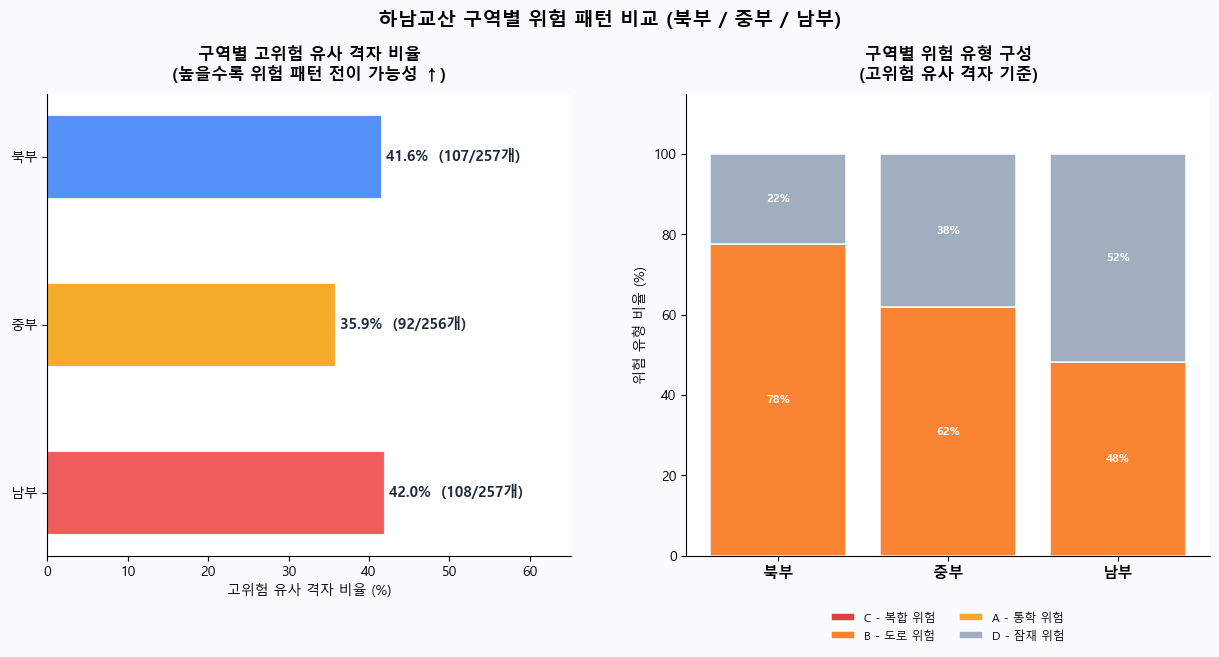

저장 완료: 04_6_구역별_위험패턴.png


In [11]:
유형_순서_4 = ['C - 복합 위험', 'B - 도로 위험', 'A - 통학 위험', 'D - 잠재 위험']
유형_색상_4 = ['#dc2626', '#f97316', '#f59e0b', '#94a3b8']

fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='#fafbfc')
fig.subplots_adjust(wspace=0.22)

# ── 왼쪽: 구역별 고위험 격자 비율 가로 막대 ───────────────────────────
ax = axes[0]
구역_stats = []
for g in 구역_순서:
    sub  = df_region[df_region['구역'] == g]
    high = int(sub['유사_고위험_여부'].sum())
    total = len(sub)
    pct  = high / total * 100 if total > 0 else 0
    구역_stats.append({'구역': g, '전체': total, '고위험': high, '비율': pct})

구역_df = pd.DataFrame(구역_stats)
colors_구역 = [구역_색상[g] for g in 구역_순서]

bars1 = ax.barh(구역_df['구역'], 구역_df['비율'],
                color=colors_구역, alpha=0.88,
                edgecolor='white', linewidth=1.5, height=0.5)
ax.invert_yaxis()

for bar, row in zip(bars1, 구역_df.itertuples()):
    ax.text(row.비율 + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{row.비율:.1f}%  ({row.고위험}/{row.전체}개)',
            va='center', fontsize=10.5, fontweight='bold', color='#1e293b')

ax.set_xlim(0, 구역_df['비율'].max() * 1.55)
ax.set_xlabel('고위험 유사 격자 비율 (%)', fontsize=10)
ax.set_title('구역별 고위험 유사 격자 비율\n(높을수록 위험 패턴 전이 가능성 ↑)',
             fontweight='bold', fontsize=12, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── 오른쪽: 구역별 위험 유형 스택 바 ──────────────────────────────────
ax2 = axes[1]
stack_data = {}
for g in 구역_순서:
    sub = df_region[(df_region['구역'] == g) & (df_region['유사_고위험_여부'] == 1)]
    total_high = len(sub)
    stack_data[g] = [
        (sub['위험_유형'] == t).sum() / total_high * 100 if total_high > 0 else 0
        for t in 유형_순서_4
    ]

x_pos   = np.arange(len(구역_순서))
bottoms = np.zeros(len(구역_순서))

for t, color in zip(유형_순서_4, 유형_색상_4):
    vals = [stack_data[g][유형_순서_4.index(t)] for g in 구역_순서]
    bars2 = ax2.bar(x_pos, vals, bottom=bottoms,
                    color=color, alpha=0.88, edgecolor='white',
                    linewidth=1.2, label=t)
    # 비율이 충분히 클 때만 내부 텍스트
    for xi, (v, bot) in enumerate(zip(vals, bottoms)):
        if v > 6:
            ax2.text(xi, bot + v / 2, f'{v:.0f}%',
                     ha='center', va='center',
                     fontsize=8.5, fontweight='bold', color='white')
    bottoms = bottoms + np.array(vals)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(구역_순서, fontsize=11, fontweight='bold')
ax2.set_ylabel('위험 유형 비율 (%)', fontsize=10)
ax2.set_ylim(0, 115)
ax2.set_title('구역별 위험 유형 구성\n(고위험 유사 격자 기준)',
              fontweight='bold', fontsize=12, pad=10)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10),
           ncol=2, fontsize=8.5, frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('하남교산 구역별 위험 패턴 비교 (북부 / 중부 / 남부)',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig(os.path.join(out, '04_6_구역별_위험패턴.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 04_6_구역별_위험패턴.png')


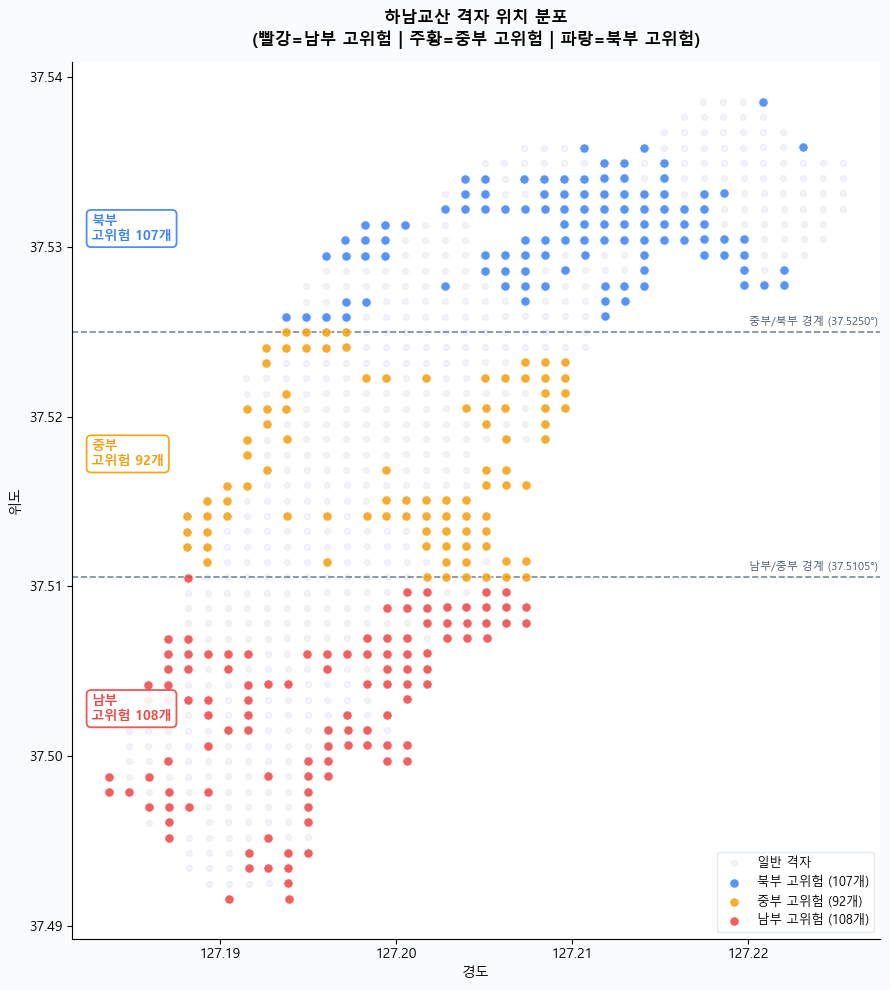

저장 완료: 04_7_구역별_격자위치.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 10), facecolor='#fafbfc')

# 일반 격자 (회색, 작게)
일반 = df_region[df_region['유사_고위험_여부'] == 0]
ax.scatter(일반['경도'], 일반['위도'],
           c='#e2e8f0', s=18, alpha=0.5, zorder=1, label='일반 격자')

# 고위험 유사 격자 (구역별 색상)
for g, color in 구역_색상.items():
    sub = df_region[(df_region['유사_고위험_여부'] == 1) & (df_region['구역'] == g)]
    ax.scatter(sub['경도'], sub['위도'],
               c=color, s=45, alpha=0.85, zorder=3,
               edgecolors='white', linewidth=0.6,
               label=f'{g} 고위험 ({len(sub)}개)')

# 구역 경계선 (위도 기준 수평선)
x_min = df_region['경도'].min() - 0.002
x_max = df_region['경도'].max() + 0.002
for lat_val, label in [(q33, f'남부/중부 경계 ({q33:.4f}°)'),
                        (q66, f'중부/북부 경계 ({q66:.4f}°)')]:
    ax.axhline(y=lat_val, color='#475569', linestyle='--',
               linewidth=1.2, alpha=0.7, zorder=2)
    ax.text(x_max, lat_val + 0.0004, label,
            ha='right', fontsize=8, color='#475569', style='italic')

# 구역 레이블 (배경 박스)
구역_중앙_위도 = {
    '남부': df_region[df_region['구역']=='남부']['위도'].mean(),
    '중부': df_region[df_region['구역']=='중부']['위도'].mean(),
    '북부': df_region[df_region['구역']=='북부']['위도'].mean(),
}
for g, mid_lat in 구역_중앙_위도.items():
    sub_h = df_region[(df_region['구역']==g) & (df_region['유사_고위험_여부']==1)]
    ax.text(x_min + 0.001, mid_lat,
            f'{g}\n고위험 {len(sub_h)}개',
            ha='left', va='center', fontsize=9.5, fontweight='bold',
            color=구역_색상[g],
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor=구역_색상[g], linewidth=1.3, alpha=0.9))

ax.set_xlabel('경도', fontsize=10)
ax.set_ylabel('위도', fontsize=10)
ax.set_title(
    '하남교산 격자 위치 분포\n(빨강=남부 고위험 | 주황=중부 고위험 | 파랑=북부 고위험)',
    fontweight='bold', fontsize=12, pad=12
)
ax.legend(loc='lower right', fontsize=9, frameon=True,
          framealpha=0.9, edgecolor='#e2e8f0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(out, '04_7_구역별_격자위치.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 04_7_구역별_격자위치.png')


In [13]:
print('=' * 65)
print('구역별 스마트 시설물 배치 제안 (PPT 슬라이드용)')
print('=' * 65)

시설_매핑 = {
    'C - 복합 위험': '스마트 횡단보도 + 과속 감지 카메라 + 스쿨존',
    'B - 도로 위험': '과속 감지 카메라 + 스마트 횡단보도',
    'A - 통학 위험': '스쿨존 강화 + 스마트 횡단보도',
    'D - 잠재 위험': '안전 표지판 + 기본 인프라 점검',
}

for g in 구역_순서:
    sub = df_region[(df_region['구역'] == g) & (df_region['유사_고위험_여부'] == 1)]
    if len(sub) == 0:
        continue
    주요_유형 = sub['위험_유형'].value_counts().idxmax()
    주요_비율 = sub['위험_유형'].value_counts(normalize=True).iloc[0] * 100
    print(f'\n[{g}] 고위험 유사 격자 {len(sub)}개')
    print(f'  주요 위험 유형: {주요_유형} ({주요_비율:.1f}%)')
    print(f'  핵심 추천 시설: {시설_매핑.get(주요_유형, "안전 표지판")}')
    print(f'  유형 분포:')
    for t, cnt in sub['위험_유형'].value_counts().items():
        print(f'    - {t}: {cnt}개 ({cnt/len(sub)*100:.1f}%)')

print()
print('=== 전체 요약 ===')
total_high = (df_region['유사_고위험_여부'] == 1).sum()
print(f'하남교산 고위험 유사 격자 총 {total_high}개')
for g in 구역_순서:
    cnt = len(df_region[(df_region['구역']==g) & (df_region['유사_고위험_여부']==1)])
    print(f'  {g}: {cnt}개 ({cnt/total_high*100:.1f}%)')


구역별 스마트 시설물 배치 제안 (PPT 슬라이드용)

[북부] 고위험 유사 격자 107개
  주요 위험 유형: B - 도로 위험 (77.6%)
  핵심 추천 시설: 과속 감지 카메라 + 스마트 횡단보도
  유형 분포:
    - B - 도로 위험: 83개 (77.6%)
    - D - 잠재 위험: 24개 (22.4%)

[중부] 고위험 유사 격자 92개
  주요 위험 유형: B - 도로 위험 (62.0%)
  핵심 추천 시설: 과속 감지 카메라 + 스마트 횡단보도
  유형 분포:
    - B - 도로 위험: 57개 (62.0%)
    - D - 잠재 위험: 35개 (38.0%)

[남부] 고위험 유사 격자 108개
  주요 위험 유형: D - 잠재 위험 (51.9%)
  핵심 추천 시설: 안전 표지판 + 기본 인프라 점검
  유형 분포:
    - D - 잠재 위험: 56개 (51.9%)
    - B - 도로 위험: 52개 (48.1%)

=== 전체 요약 ===
하남교산 고위험 유사 격자 총 307개
  북부: 107개 (34.9%)
  중부: 92개 (30.0%)
  남부: 108개 (35.2%)


---
## [J-1] 4시구 유사격자 실제 사고 역추적 — 하남교산 위험 예방 시나리오

> **핵심 질문**: 하남교산과 토지 유사도가 높은 4시구 격자들의 실제 사고 이력이 어떻게 되는가?

- "하남교산의 307개 고위험 예측 격자와 유사한 4시구 격자에서는 실제로 X건의 사고가 있었다"
- "그 중 어린이보호구역 내 사고가 Y건 = 하남교산에 동일한 인프라가 없다면 같은 위험이 반복될 수 있다"
- **예방 시나리오**: 인프라를 선제 배치하면 회피 가능한 사고 수를 수치로 제시

> 분석 대상: `하남교산_유사격자_매칭.csv`의 `유사_4시구_gid` → `격자_미성년자_분석_정규화.csv`와 조인


✅ 매칭 데이터: 770행
✅ 격자 정규화: 99,679행

유사 4시구 격자 수: 336개 (하남교산 전체 770개 대응)

매칭된 4시구 격자 중 데이터 있는 격자: 348개

사고 관련 컬럼: ['격자내_어린이보호구역_어린이사고_건수', '격자내_미성년자_교통사고_건수', '격자내_등하교시간대_미성년자_사고_건수', '정규화_교통사고']

=== 4시구 유사격자 실제 사고 이력 ===
  격자내_어린이보호구역_어린이사고_건수: 총 3건  (사고 발생 격자: 1개 / 348개)
  격자내_미성년자_교통사고_건수: 총 24건  (사고 발생 격자: 17개 / 348개)
  격자내_등하교시간대_미성년자_사고_건수: 총 11건  (사고 발생 격자: 9개 / 348개)
  정규화_교통사고: 총 6건  (사고 발생 격자: 17개 / 348개)

[핵심 메시지] 하남교산 예측 고위험 격자(770개)와 토지 유사한
  4시구 격자들에서 실제로 3건의 [격자내_어린이보호구역_어린이사고_건수]이(가) 발생했습니다.
  (1개 격자, 전체 유사격자의 0.3%에서 사고)

  → 하남교산에 동일한 토지 구조가 형성되었을 때, 인프라 없이 방치하면
    유사한 규모의 사고 위험이 현실화될 수 있습니다.
  → 지금 설계 단계에서 인프라를 선제 배치하면 이 위험을 크게 줄일 수 있습니다.


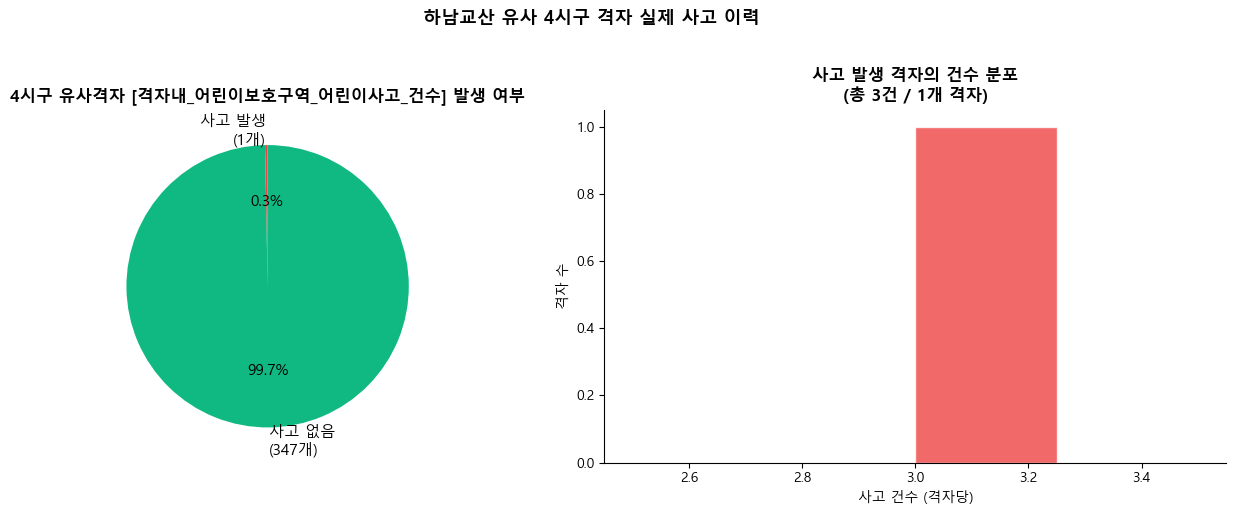


4시구 사고 역추적 분석 완료


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic' if os.name == 'nt' else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ─────────────────────────────────────────────────────────────
candidates = ['../../data/', '../data/', '../../../data/']
out = None
for p in candidates:
    probe = os.path.join(p, '통합_데이터')
    if os.path.exists(probe):
        out = probe
        break

def load_csv(path, enc=('utf-8', 'utf-8-sig', 'cp949')):
    for e in enc:
        try: return pd.read_csv(path, encoding=e)
        except: continue
    return None

# 매칭 파일
매칭_path = os.path.join(out, '하남교산_유사격자_매칭.csv') if out else None
정규화_path = os.path.join(out, '격자_미성년자_분석_정규화.csv') if out else None

if not (매칭_path and os.path.exists(매칭_path)):
    print('⚠ 하남교산_유사격자_매칭.csv 없음 → 03_하남교산_유사격자_매칭.ipynb 먼저 실행')
elif not (정규화_path and os.path.exists(정규화_path)):
    print('⚠ 격자_미성년자_분석_정규화.csv 없음 → 05_정규화.ipynb 먼저 실행')
else:
    하남_매칭 = load_csv(매칭_path)
    격자_정규화 = load_csv(정규화_path)
    print(f'✅ 매칭 데이터: {len(하남_매칭):,}행')
    print(f'✅ 격자 정규화: {len(격자_정규화):,}행')

    # ── 유사_4시구_gid 추출 ──────────────────────────────────────────────────
    유사_gid_목록 = 하남_매칭['유사_4시구_gid'].dropna().unique().tolist()
    print(f'\n유사 4시구 격자 수: {len(유사_gid_목록):,}개 (하남교산 전체 {len(하남_매칭):,}개 대응)')

    # ── 4시구 격자의 사고 이력 조인 ──────────────────────────────────────
    사고_cols = [c for c in 격자_정규화.columns if '사고' in c or '건수' in c]
    필요_cols = ['gid'] + 사고_cols
    필요_cols = [c for c in 필요_cols if c in 격자_정규화.columns]

    유사_4시구 = 격자_정규화[격자_정규화['gid'].isin(유사_gid_목록)][필요_cols]
    print(f'\n매칭된 4시구 격자 중 데이터 있는 격자: {len(유사_4시구):,}개')

    if not 사고_cols:
        print('⚠ 사고 건수 관련 컬럼 탐지 실패')
        print(f'   현재 컬럼 일부: {list(격자_정규화.columns[:15])}')
    else:
        print(f'\n사고 관련 컬럼: {사고_cols}')
        print('\n=== 4시구 유사격자 실제 사고 이력 ===')
        for col in 사고_cols:
            총계 = 유사_4시구[col].sum()
            유사_격자_수 = (유사_4시구[col] > 0).sum()
            print(f'  {col}: 총 {총계:.0f}건  (사고 발생 격자: {유사_격자_수:,}개 / {len(유사_4시구):,}개)')

        # 가장 기본 사고 컬럼 선택
        주요_사고_col = next((c for c in 사고_cols if '미성년자' in c or '어린이' in c), 사고_cols[0])
        총_사고 = 유사_4시구[주요_사고_col].sum()
        사고_격자 = (유사_4시구[주요_사고_col] > 0).sum()

        print(f'\n[핵심 메시지] 하남교산 예측 고위험 격자({len(하남_매칭):,}개)와 토지 유사한')
        print(f'  4시구 격자들에서 실제로 {총_사고:.0f}건의 [{주요_사고_col}]이(가) 발생했습니다.')
        print(f'  ({사고_격자:,}개 격자, 전체 유사격자의 {사고_격자/len(유사_4시구)*100:.1f}%에서 사고)')
        print(f'\n  → 하남교산에 동일한 토지 구조가 형성되었을 때, 인프라 없이 방치하면')
        print(f'    유사한 규모의 사고 위험이 현실화될 수 있습니다.')
        print(f'  → 지금 설계 단계에서 인프라를 선제 배치하면 이 위험을 크게 줄일 수 있습니다.')

        # ── 시각화 ─────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # 왼쪽: 사고 발생 유무 파이 차트
        ax1 = axes[0]
        사고_있음 = (유사_4시구[주요_사고_col] > 0).sum()
        사고_없음 = (유사_4시구[주요_사고_col] == 0).sum()
        ax1.pie([사고_있음, 사고_없음],
                labels=[f'사고 발생\n({사고_있음:,}개)', f'사고 없음\n({사고_없음:,}개)'],
                colors=['#ef4444', '#10b981'],
                autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 11})
        ax1.set_title(f'4시구 유사격자 [{주요_사고_col}] 발생 여부', fontweight='bold')

        # 오른쪽: 사고 건수 분포 히스토그램
        ax2 = axes[1]
        사고_발생_격자 = 유사_4시구[유사_4시구[주요_사고_col] > 0][주요_사고_col]
        if len(사고_발생_격자) > 0:
            ax2.hist(사고_발생_격자, bins=min(20, int(사고_발생_격자.max())+1),
                     color='#ef4444', alpha=0.8, edgecolor='white')
            ax2.set_xlabel('사고 건수 (격자당)')
            ax2.set_ylabel('격자 수')
            ax2.set_title(f'사고 발생 격자의 건수 분포\n(총 {총_사고:.0f}건 / {사고_있음:,}개 격자)', fontweight='bold')
            ax2.spines['top'].set_visible(False)
            ax2.spines['right'].set_visible(False)
        else:
            ax2.text(0.5, 0.5, '사고 데이터 없음', ha='center', va='center', fontsize=12)

        plt.suptitle('하남교산 유사 4시구 격자 실제 사고 이력', fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

        print('\n4시구 사고 역추적 분석 완료')
